# Major Studios Works Analysis
Analyze the number of works produced by major anime studios over the years. Identify trends in production volume and highlight any significant changes or patterns.

In [22]:
import duckdb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import lib.dbconnection as dbc

sns.set_theme(style="whitegrid")

# --- 1. IDENTIFICARE GLI ANIME "DI SUCCESSO" (DuckDB su Parquet) ---

In [23]:
PARQUET_PATH = '../../../cleaned_data/ratings_cleaned.parquet'

query_success = f"""
    SELECT
        anime_id,
        AVG(score) as avg_score,
        COUNT(score) as vote_count
    FROM read_parquet('{PARQUET_PATH}')
    WHERE score > 0
    GROUP BY anime_id
    HAVING AVG(score) >= 7.5 AND COUNT(score) > 50
"""

print("1. Estrazione anime di successo (DuckDB)...")
df_successful_anime = duckdb.sql(query_success).df()
print(f"Trovati {len(df_successful_anime)} anime con media alta.")

Trovati 1473 anime con media alta.


# --- 2. CARICAMENTO E PULIZIA (Postgres + Pandas) ---


In [24]:
if not df_successful_anime.empty:
    engine = dbc.create_db_engine()

    query_works = "SELECT person_mal_id, anime_mal_id, position FROM person_anime_works"
    query_people = "SELECT person_mal_id, name FROM person_details"

    df_works = pd.read_sql(query_works, engine)
    df_people = pd.read_sql(query_people, engine)

    successful_ids = df_successful_anime['anime_id'].unique()
    df_works_success = df_works[df_works['anime_mal_id'].isin(successful_ids)]

    prolific_creators = df_works_success.groupby('person_mal_id')['anime_mal_id'].nunique().reset_index()
    prolific_creators.columns = ['person_mal_id', 'successful_works_count']

    top_creators = pd.merge(prolific_creators, df_people, on='person_mal_id', how='left')
    top_15_creators = top_creators.sort_values(by='successful_works_count', ascending=False).head(15)

else:
    print("Nessun anime trovato. Controlla il percorso del file Parquet o abbassa la soglia del voto.")


# --- 3. PULIZIA E INCROCIO DATI (Pandas) ---

In [25]:
print("3. Elaborazione e Type Casting...")

successful_ids = df_successful_anime['anime_id'].unique()
df_works_success = df_works[df_works['anime_mal_id'].isin(successful_ids)]

prolific_creators = df_works_success.groupby('person_mal_id')['anime_mal_id'].nunique().reset_index()
prolific_creators.columns = ['person_mal_id', 'successful_works_count']

top_creators = pd.merge(prolific_creators, df_people, on='person_mal_id', how='left')

top_15_creators = top_creators.sort_values(by='successful_works_count', ascending=False).head(15)

print("Analisi completata. Ecco i primi risultati:")
print(top_15_creators[['name', 'successful_works_count']])

3. Elaborazione e Type Casting...
Analisi completata. Ecco i primi risultati:
Empty DataFrame
Columns: [name, successful_works_count]
Index: []


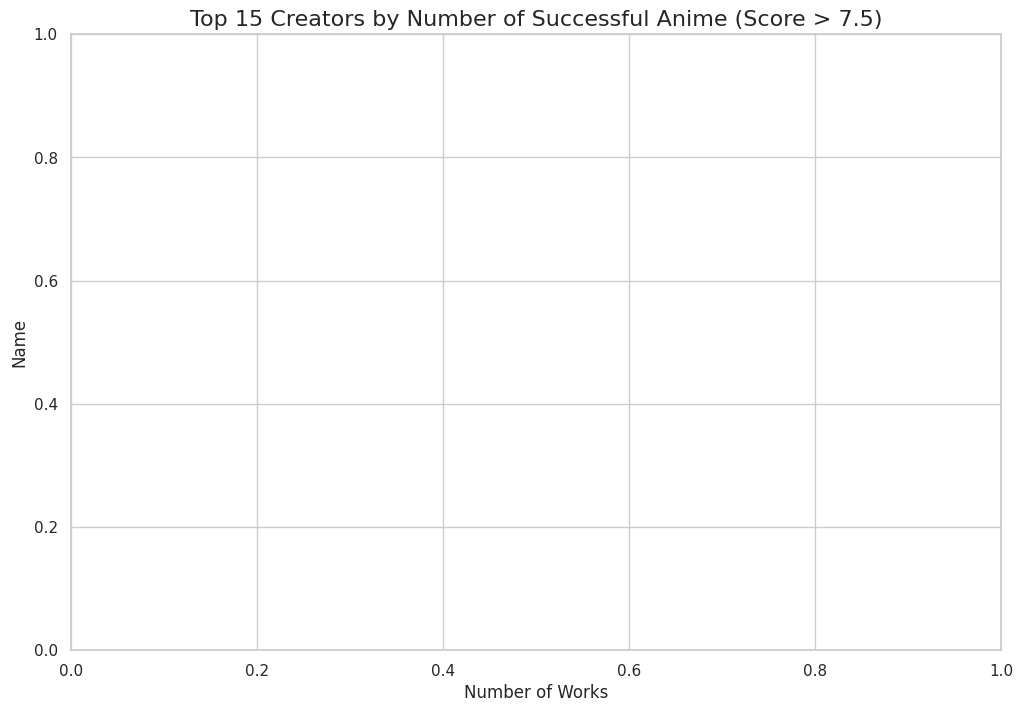

In [26]:
plt.figure(figsize=(12, 8))
sns.barplot(
    data=top_15_creators,
    x='successful_works_count',
    y='name',
    hue='name',
    palette='viridis'
)
plt.title('Top 15 Creators by Number of Successful Anime (Score > 7.5)', fontsize=16)
plt.xlabel('Number of Works')
plt.ylabel('Name')

plt.savefig('../../graphs/creatorsBySuccessfulAnime.png', dpi=300, bbox_inches='tight')
plt.show()